In [22]:
import sys

sys.path.append("/Users/ikergg/Documents/Python learning/Proyectos/Empezando")

import os
from dotenv import load_dotenv

load_dotenv("/Users/ikergg/Documents/Python learning/Proyectos/Empezando/.env")
FRED_KEY = os.getenv("FRED_KEY")

import pandas as pd
import numpy as np
import scipy
import time
from datetime import datetime, timedelta
import requests
import matplotlib.pyplot as plt
import cvxpy as cp
import streamlit as st
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame

load_dotenv()
ALPACA_KEY = os.getenv("ALPACA_KEY")
ALPACA_SECRET = os.getenv("ALPACA_SECRET")
client = StockHistoricalDataClient(ALPACA_KEY,  ALPACA_SECRET)

In [23]:
def get_returns_cvar(symbol : str, START_DATE : str = "2016-01-01" ) -> pd.Series:
    "Download the rickers data"
    try:
        END_DATE= datetime.now()
        
        params = StockBarsRequest(
            symbol_or_symbols= symbol,
            timeframe=TimeFrame.Day,
            start=START_DATE,
            end=END_DATE,
            feed="iex"
        )

        bars = client.get_stock_bars(params)
        df = bars.df.reset_index()
        
        if "symbol" in df.columns:
            df = df[df["symbol"]== symbol]
            
        df["returns"] = (df["close"] / df["close"].shift(-1)).apply(lambda x: np.log(x))
        
        return df["returns"].dropna()

    except:
        return

In [24]:
get_returns_cvar("AAPL")

0       0.016609
1      -0.018320
2      -0.012783
3      -0.099839
4      -0.022868
          ...   
1434    0.001371
1435   -0.028702
1436    0.011272
1437   -0.025792
1438   -0.010511
Name: returns, Length: 1439, dtype: float64

In [25]:
symbols= ["AAPL", "MSFT", "NVDA", "AMZN", "TSLA", "GOOGL", "META", "JPM", "XOM", "NFLX"]


data = {s: get_returns_cvar(s) for s in symbols}
df = pd.DataFrame(data)
    
    
    

In [26]:
print(df.head())
print(df.shape)


       AAPL      MSFT      NVDA      AMZN      TSLA     GOOGL      META  \
0  0.016609  0.008325  0.018799  0.018290  0.041860  0.016193  0.015788   
1 -0.018320 -0.009894 -0.023381 -0.011368 -0.013382 -0.012603 -0.014117   
2 -0.012783  0.001471 -0.012786 -0.005472  0.007888 -0.008581 -0.006069   
3 -0.099839 -0.005576  0.000637 -0.036375  0.038262  0.032118 -0.077926   
4 -0.022868 -0.055089 -0.037928  0.016453 -0.036654  0.003642  0.007994   

        JPM       XOM      NFLX  
0 -0.005044  0.012208  0.016178  
1 -0.023292 -0.011528  0.007383  
2  0.027975  0.051102 -0.002144  
3  0.004446 -0.004885 -0.006795  
4  0.004258 -0.004624 -0.019188  
(1439, 10)


In [ ]:
def cvar_initial(df : pd.DataFrame) -> tuple:
    R = df.dropna().values
    T, N = R.shape
    alpha = 0.05  # worst 5%

    w = cp.Variable(N)
    zeta = cp.Variable()
    u = cp.Variable(T)

    portfolio_losses = -R @ w

    cvar = zeta + (1 / (alpha * T)) * cp.sum(u)

    constraints = [
        u >= portfolio_losses - zeta,
        u >= 0,
        cp.sum(w) == 1,
        w >= 0,
    ]

    prob = cp.Problem(cp.Minimize(cvar), constraints)
    prob.solve()

    print(f"CVaR: {cvar.value:.4f}")
    print(f"VaR:  {zeta.value:.4f}")
    print(pd.Series(w.value, index=df.columns).round(4))
    
    return cvar, zeta, w

CVaR: 0.0222
VaR:  0.0164
AAPL     0.1183
MSFT     0.2321
NVDA     0.0014
AMZN     0.0245
TSLA     0.0000
GOOGL    0.0231
META     0.0000
JPM      0.3815
XOM      0.1679
NFLX     0.0512
dtype: float64


In [30]:
def cvar_efficient_frontier(df : pd.DataFrame, alpha : float = 0.05, n_points : int = 50 ) -> pd.DataFrame:
    "loop through min to max posible points to get the frontier"
    
    R = df.dropna().values
    T, N = R.shape

    mean_return = R.mean(axis = 0)
    min_return = mean_return.min()
    max_return = mean_return.max()
    targets = np.linspace(min_return, max_return, n_points)
    
    frontier = []
    
    for target in targets:
        
        w = cp.Variable(N)
        zeta = cp.Variable()
        u = cp.Variable(T)

        portfolio_losses = -R @ w
        cvar = zeta + (1 / (alpha * T)) * cp.sum(u)

        constraints = [
            u >= portfolio_losses - zeta,
            u >= 0,
            cp.sum(w) == 1,
            w >= 0,
            (R @ w) @ np.ones(T) / T >= target,
        ]
        
        prob = cp.Problem(cp.Minimize(cvar), constraints)
        prob.solve()
        
        if prob.status in ["optimal", "optimal_inaccurate"]:
            frontier.append({
                "target_return": target,
                "cvar": cvar.value,
                "weights": pd.Series(w.value, index=df.columns),
            })
        
    return pd.DataFrame([{"target_return": f["target_return"], "cvar": f["cvar"]} for f in frontier]), frontier

In [31]:
frontier_df, frontier_full = cvar_efficient_frontier(df)
print(frontier_df)

    target_return      cvar
0       -0.000842  0.022231
1       -0.000789  0.022231
2       -0.000736  0.022231
3       -0.000683  0.022231
4       -0.000630  0.022231
5       -0.000577  0.022231
6       -0.000525  0.022231
7       -0.000472  0.022231
8       -0.000419  0.022231
9       -0.000366  0.022239
10      -0.000313  0.022265
11      -0.000260  0.022321
12      -0.000207  0.022385
13      -0.000155  0.022473
14      -0.000102  0.022581
15      -0.000049  0.022702
16       0.000004  0.022828
17       0.000057  0.023005
18       0.000110  0.023224
19       0.000162  0.023472
20       0.000215  0.023763
21       0.000268  0.024097
22       0.000321  0.024509
23       0.000374  0.024943
24       0.000427  0.025419
25       0.000479  0.025938
26       0.000532  0.026499
27       0.000585  0.027082
28       0.000638  0.027743
29       0.000691  0.028445
30       0.000744  0.029182
31       0.000796  0.029953
32       0.000849  0.030749
33       0.000902  0.031589
34       0.000955  0

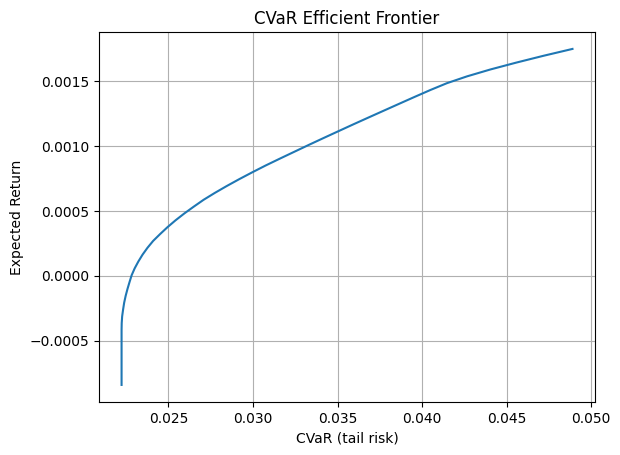

In [32]:
import matplotlib.pyplot as plt

plt.plot(frontier_df["cvar"], frontier_df["target_return"])
plt.xlabel("CVaR (tail risk)")
plt.ylabel("Expected Return")
plt.title("CVaR Efficient Frontier")
plt.grid(True)
plt.show()

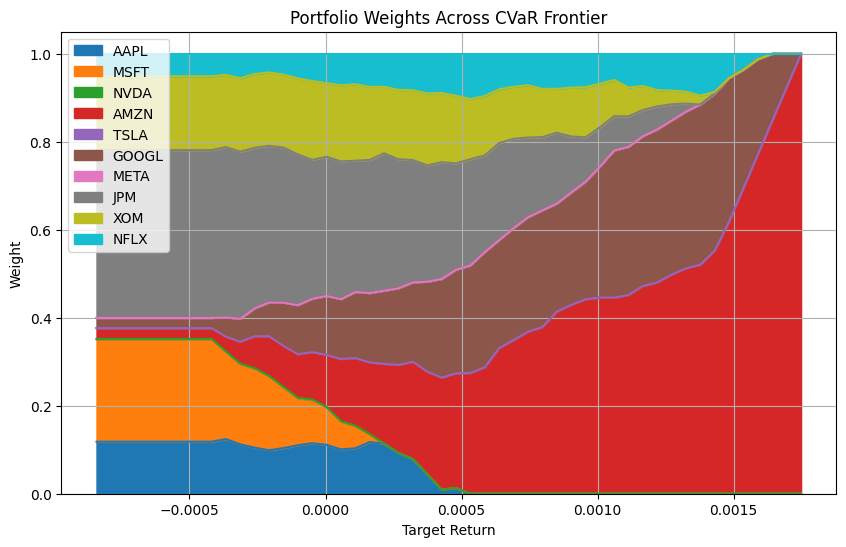

In [ ]:
def cvar_weights(frontier_full : pd.DataFrame): 
    weights_df = pd.DataFrame(
        [f["weights"] for f in frontier_full],
        index=frontier_df["target_return"]
    )

    weights_df = weights_df.clip(lower=0)
    weights_df = weights_df.div(weights_df.sum(axis=1), axis=0)
    
    return weights_df

weights_df = cvar_weights(frontier_df, frontier_full)

weights_df.plot.area(figsize=(10, 6))
plt.xlabel("Target Return")
plt.ylabel("Weight")
plt.title("Portfolio Weights Across CVaR Frontier")
plt.legend(loc="upper left")
plt.grid(True)
plt.show()